# LangGraph Agent
## _With_ tools

## Library Imports

In [1]:
from swc_toolkit import SportsWorldCentralToolkit
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode
from typing import Literal

from langchain_core.messages import HumanMessage
from langchain_anthropic import ChatAnthropic
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, START, StateGraph, MessagesState
import logging
from IPython.display import Image, Markdown, display
from langchain_core.runnables.graph import CurveStyle, MermaidDrawMethod, NodeStyles

SWC_API_BASE_URL in SWCConfig init: http://0.0.0.0:8000


/usr/local/python/3.12.1/lib/python3.12/site-packages/langgraph/checkpoint/base/__init__.py:18: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


## Configure logging

In [2]:
for handler in logging.root.handlers[:]:
    logging.root.removeHandler(handler)

logging.basicConfig(
    filename='langgraph_notebook.log',
    level=logging.INFO,
)

## Create Toolkit

In [3]:
swc_toolkit = SportsWorldCentralToolkit()
tools = swc_toolkit.get_tools()

## Configure Agent and Model

In [4]:
tool_node = ToolNode(tools)

model = ChatAnthropic(model='claude-sonnet-4-6', temperature=0).bind_tools(tools)

def should_continue(state: MessagesState) -> Literal["tools", END]:
    messages = state["messages"]
    last_message = messages[-1]
    if last_message.tool_calls:
        return "tools"
    return END

def call_model(state: MessagesState):
    messages = state['messages']
    response = model.invoke(messages)
    return {"messages": [response]}

workflow = StateGraph(MessagesState)
workflow.add_node("agent", call_model)
workflow.add_node("tools", tool_node)
workflow.add_edge(START, "agent")
workflow.add_conditional_edges("agent", should_continue)
workflow.add_edge("tools", "agent")

checkpointer = MemorySaver()
app = workflow.compile(checkpointer=checkpointer)


## Visualize the Graph

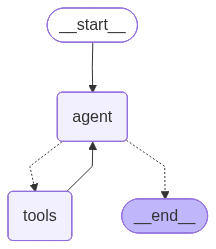

In [5]:
display(
    Image(
        app.get_graph().draw_mermaid_png(
            draw_method = MermaidDrawMethod.API
        )
    )
)

## Chat with the Agent

In [7]:
final_state = app.invoke(
    {"messages":[HumanMessage(content = "What teams did Joe Montana play for?")]},
    config = {"configurable":{"thread_id":99}}
)
display(Markdown(final_state["messages"][-1].content))

I was able to retrieve all the teams and their players from SportsWorldCentral, but **Joe Montana does not appear on any of the teams** in the system. He is not listed as a player on any roster in the database.

It's worth noting that SportsWorldCentral appears to be a **fantasy football platform**, and Joe Montana is a retired NFL legend, so it makes sense that he wouldn't be on any active fantasy rosters.

From general knowledge, Joe Montana's real NFL career teams were:
- **San Francisco 49ers** (1979–1992)
- **Kansas City Chiefs** (1993–1994)

If you're looking for a specific player currently in the SportsWorldCentral system, I'd be happy to help!

In [8]:
final_state = app.invoke(
    {"messages":[HumanMessage(content = "What are the leagues in the SportsWorldCentral fantasy football platform? Keep the response simple.")]},
    config = {"configurable":{"thread_id":99}}
)
display(Markdown(final_state["messages"][-1].content))

Here are the 5 leagues in SportsWorldCentral:

1. **Pigskin Prodigal Fantasy League** (PPR)
2. **Recurring Champions League** (Half-PPR)
3. **AHAHFZZFFFL** (Half-PPR)
4. **Gridiron Gurus Fantasy League** (PPR)
5. **Best League Ever** (PPR)